In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
fake = pd.read_csv('../dataset/Fake.csv')
real = pd.read_csv('../dataset/True.csv')

print("Fake news articles:", len(fake))
print("Real news articles:", len(real))
print("\nFake columns:", fake.columns.tolist())
print("\nFirst row:")
print(fake.head(1))

Fake news articles: 23481
Real news articles: 21417

Fake columns: ['title', 'text', 'subject', 'date']

First row:
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   

                date  
0  December 31, 2017  


In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to C:\Users\M S
[nltk_data]     I\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\M S
[nltk_data]     I\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt to C:\Users\M S
[nltk_data]     I\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package omw-1.4 to C:\Users\M S
[nltk_data]     I\AppData\Roaming\nltk_data...


True

In [3]:
fake = pd.read_csv('../dataset/Fake.csv')
real = pd.read_csv('../dataset/True.csv')
fake['label'] = 0  # 0 = Fake
real['label'] = 1  # 1 = Real
df = pd.concat([fake, real], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("✅ Dataset loaded successfully!")
print(f"Total articles : {len(df)}")
print(f"Fake articles  : {len(df[df['label']==0])}")
print(f"Real articles  : {len(df[df['label']==1])}")
print(f"\nColumns: {df.columns.tolist()}")

✅ Dataset loaded successfully!
Total articles : 44898
Fake articles  : 23481
Real articles  : 21417

Columns: ['title', 'text', 'subject', 'date', 'label']


In [4]:
print("=== First 3 rows ===")
print(df.head(3))
print("\n=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

=== First 3 rows ===
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   

                  date  label  
0    February 13, 2017      0  
1       April 5, 2017       1  
2  September 27, 2017       1  

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label

In [5]:
print("Missing values before cleaning:")
print(df.isnull().sum())
df.dropna(subset=['text', 'title'], inplace=True)
df = df[df['text'].str.strip() != '']
df = df[df['title'].str.strip() != '']
df.reset_index(drop=True, inplace=True)
print(f"\n✅ Missing values handled!")
print(f"Dataset size after cleaning: {len(df)}")

Missing values before cleaning:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

✅ Missing values handled!
Dataset size after cleaning: 44267


In [6]:
df['combined'] = df['title'] + ' ' + df['text']

print("✅ Title and text combined!")
print("\nExample combined text (first 300 chars):")
print(df['combined'][0][:300])

✅ Title and text combined!

Example combined text (first 300 chars):
Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements 


In [11]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
        text = str(text)
        text = text.lower()
        text = re.sub(r'https?://\S+|www\.\S+', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        text = re.sub(r'[^a-z\s]', '', text)
        tokens = text.split()
        tokens = [t for t in tokens if t not in stop_words]
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
        return ' '.join(tokens)

print("✅ Preprocessing function defined!")

✅ Preprocessing function defined!


In [12]:
print("Preprocessing text... please wait...")

df['clean_text'] = df['combined'].apply(preprocess_text)

print("✅ Preprocessing complete!")
print(f"\nOriginal text sample:\n{df['combined'][0][:200]}")
print(f"\nCleaned text sample:\n{df['clean_text'][0][:200]}")

Preprocessing text... please wait...
✅ Preprocessing complete!

Original text sample:
Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame

Cleaned text sample:
ben stein call th circuit court committed coup dtat constitution st century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film ferris bueller day m


In [13]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

print("=== Text Length Statistics ===")
print(df['word_count'].describe())
df = df[df['word_count'] >= 10]
df.reset_index(drop=True, inplace=True)

print(f"\n✅ Short articles removed!")
print(f"Final dataset size: {len(df)}")

=== Text Length Statistics ===
count    44267.000000
mean       241.271760
std        198.840486
min          0.000000
25%        130.000000
50%        213.000000
75%        298.000000
max       4854.000000
Name: word_count, dtype: float64

✅ Short articles removed!
Final dataset size: 44223


In [14]:
import os
os.makedirs('saved_models', exist_ok=True)
df[['clean_text', 'label', 'word_count']].to_csv('cleaned_data.csv', index=False)

print("✅ Cleaned data saved as 'cleaned_data.csv'!")
print(f"Final shape: {df[['clean_text','label']].shape}")
print(f"\nClass distribution:")
print(df['label'].value_counts())

✅ Cleaned data saved as 'cleaned_data.csv'!
Final shape: (44223, 2)

Class distribution:
label
0    22807
1    21416
Name: count, dtype: int64


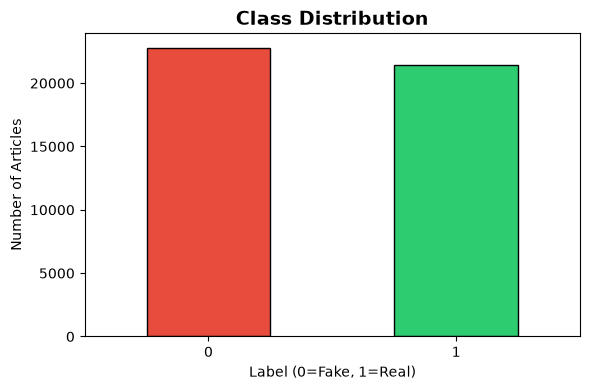

✅ Chart saved!


In [15]:
plt.figure(figsize=(6, 4))
colors = ['#e74c3c', '#2ecc71']
df['label'].value_counts().plot(
    kind='bar',
    color=colors,
    edgecolor='black'
)
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Label (0=Fake, 1=Real)')
plt.ylabel('Number of Articles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()
print("✅ Chart saved!")